<a href="https://colab.research.google.com/github/RajeshworM/Yield_Modelling_Automation/blob/main/Basmati_Scatter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving forScatter6.csv to forScatter6 (2).csv


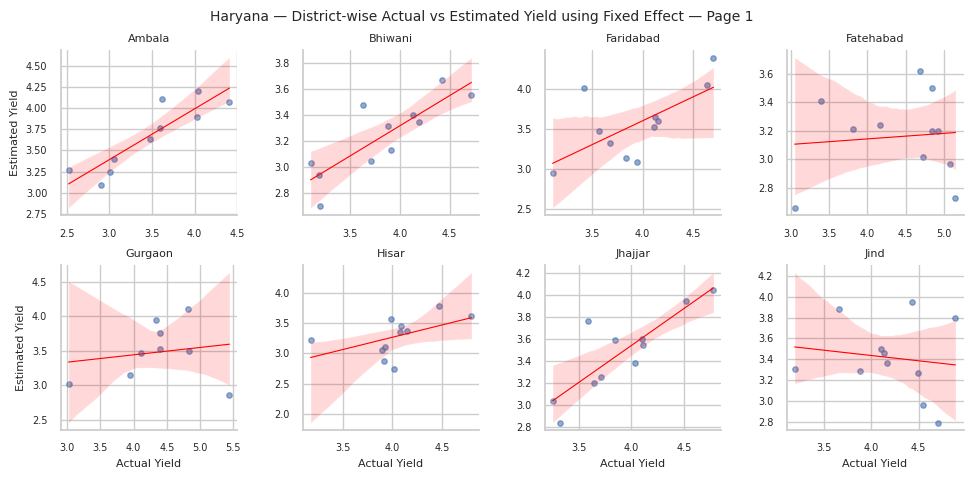

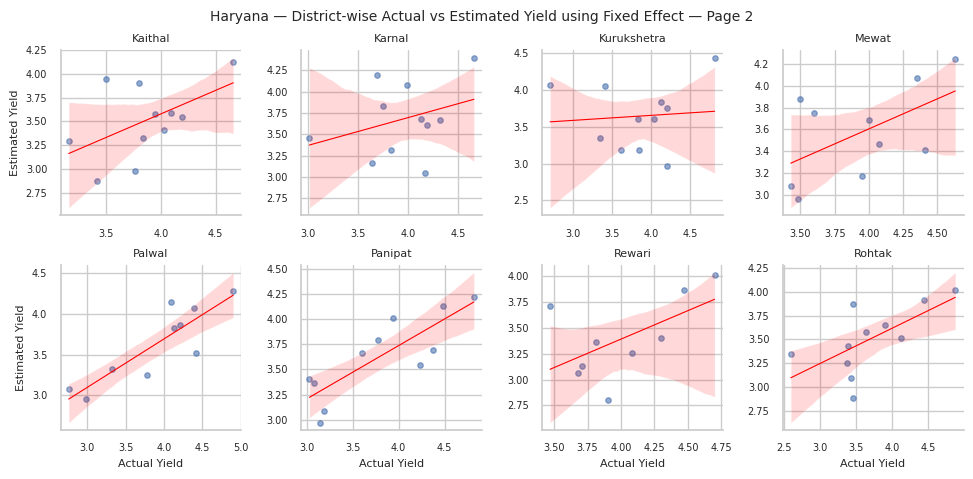

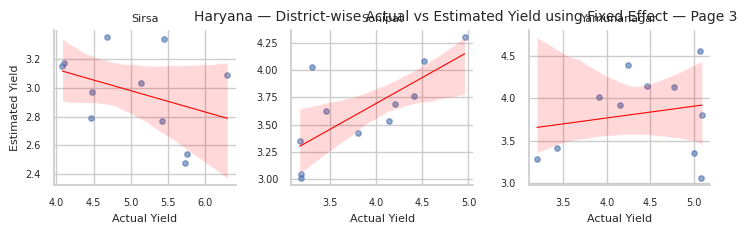

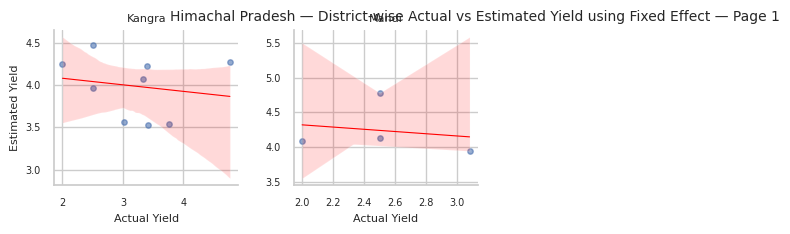

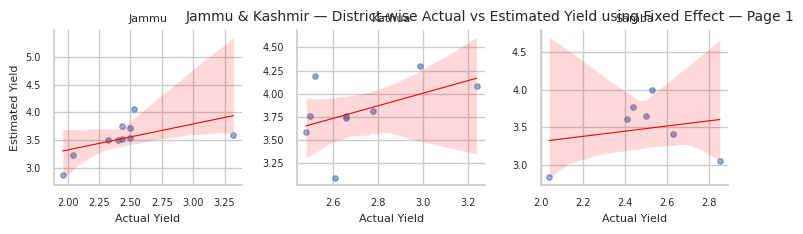

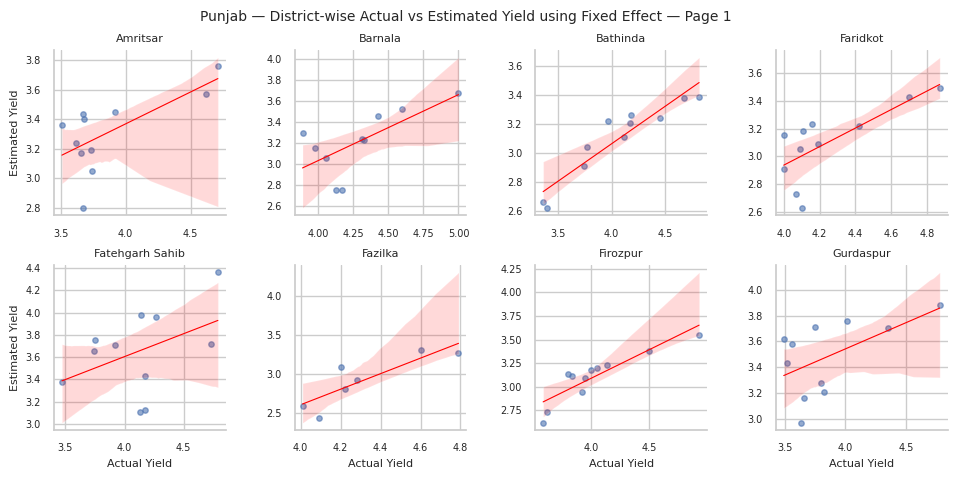

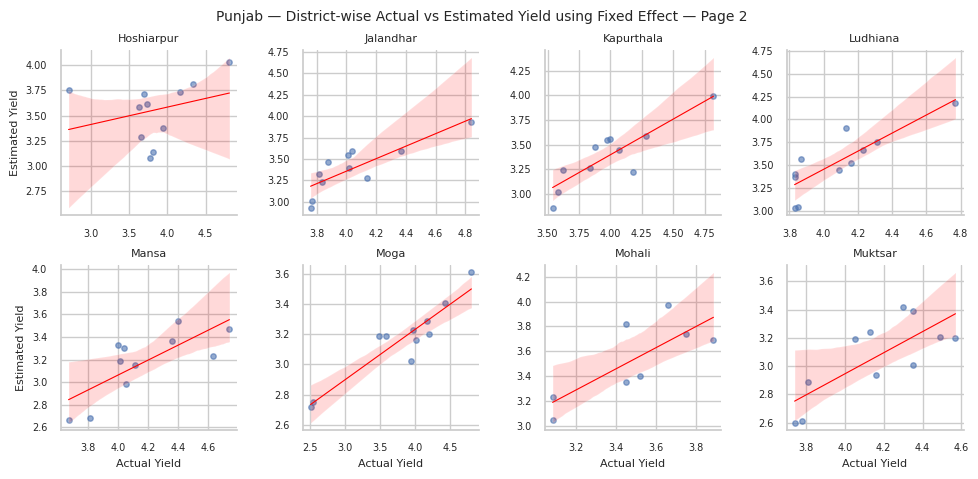

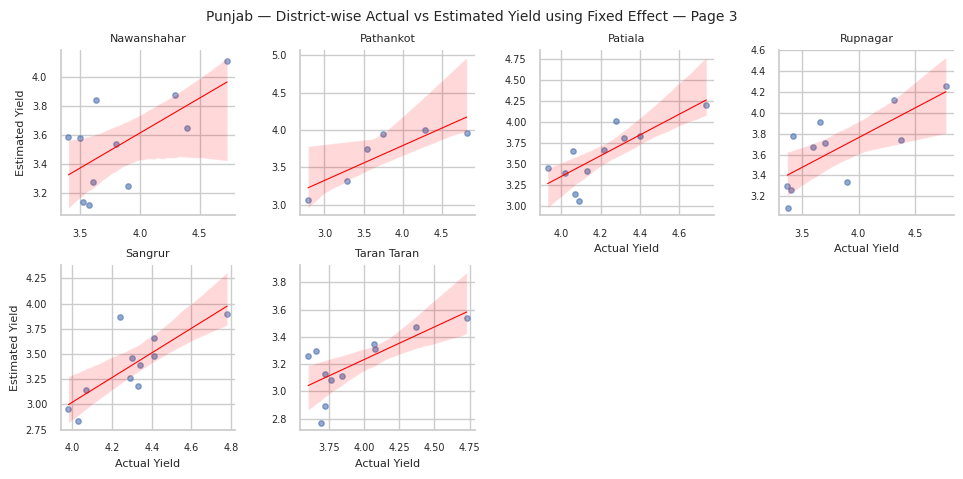

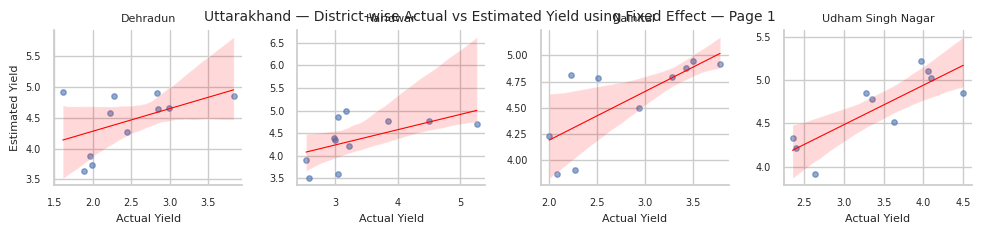

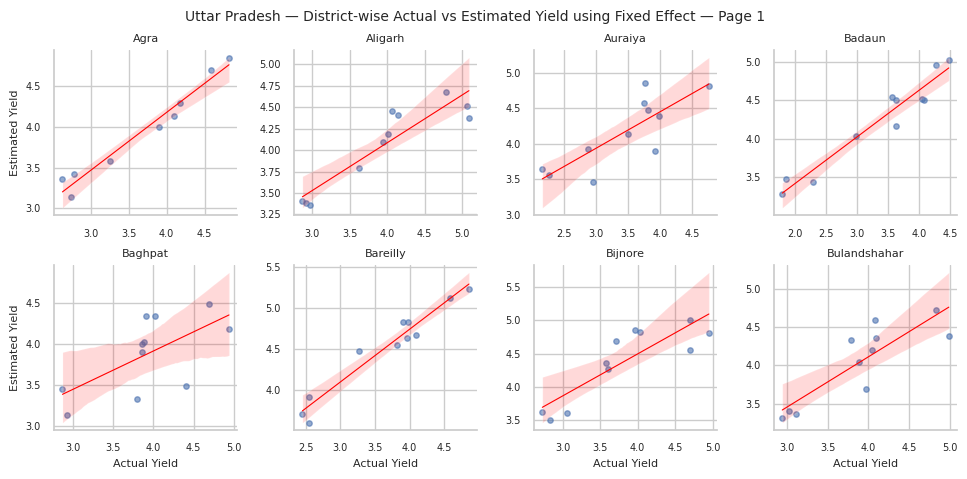

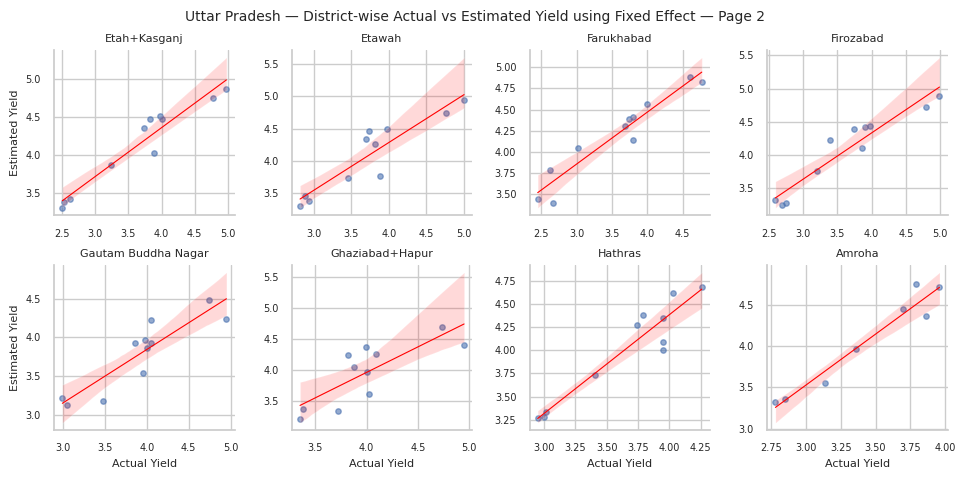

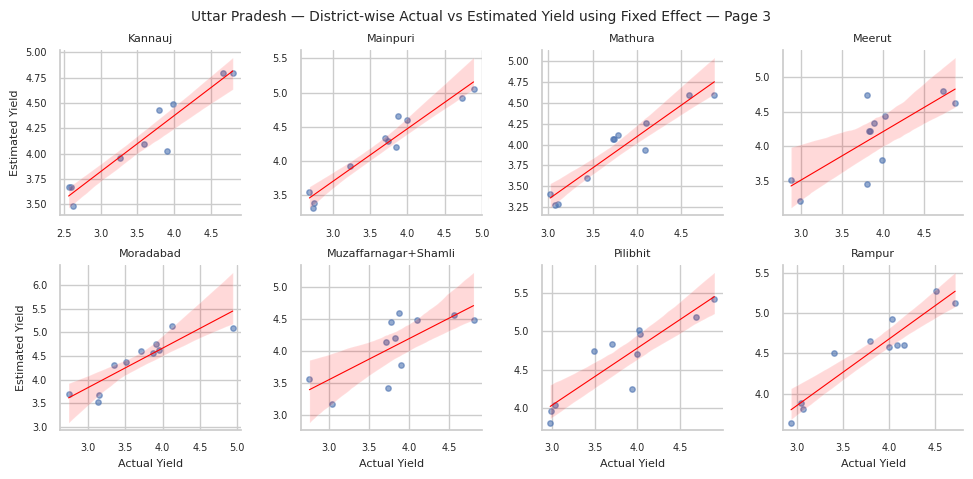

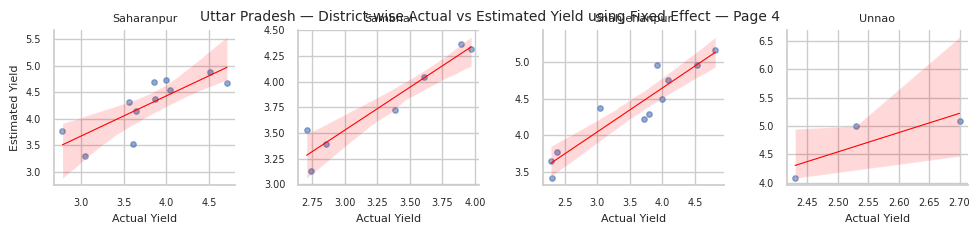

/tmp/ipython-input-3626820577.py:77: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(rmse_percent)
/tmp/ipython-input-3626820577.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


               State              District   RMSE (%)
0            Haryana                Ambala  12.239012
1            Haryana               Bhiwani  14.371796
2            Haryana             Faridabad  14.702701
3            Haryana             Fatehabad  31.666054
4            Haryana               Gurgaon  24.666299
5            Haryana                 Hisar  20.273919
6            Haryana               Jhajjar  11.293867
7            Haryana                  Jind  23.398782
8            Haryana               Kaithal  13.053196
9            Haryana                Karnal  14.421264
10           Haryana           Kurukshetra  15.122770
11           Haryana                 Mewat  15.244653
12           Haryana                Palwal  10.365470
13           Haryana               Panipat   8.101479
14           Haryana                Rewari  18.334688
15           Haryana                Rohtak  13.376130
16           Haryana                 Sirsa  44.814344
17           Haryana        

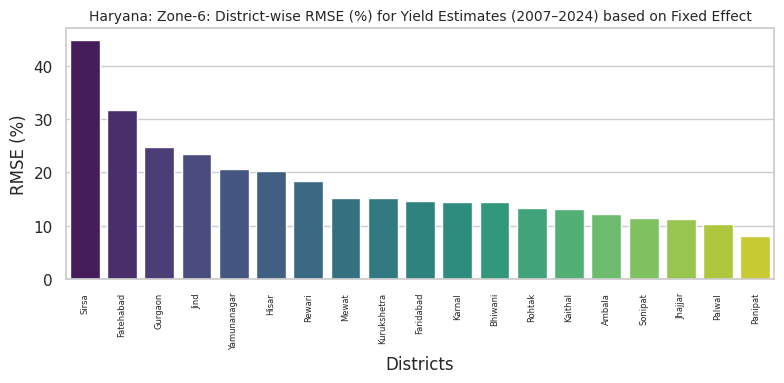

/tmp/ipython-input-3626820577.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


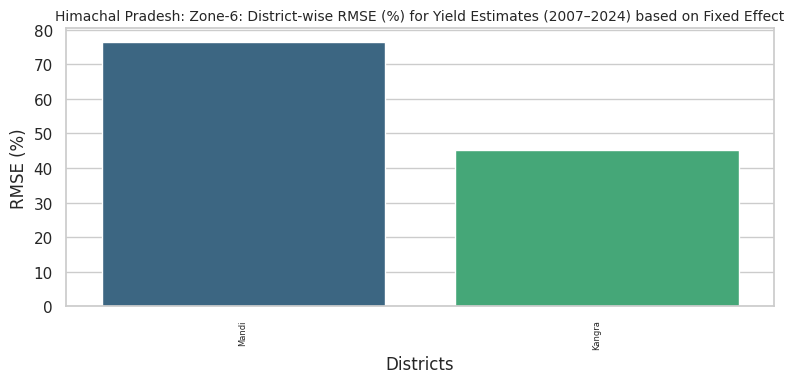

/tmp/ipython-input-3626820577.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


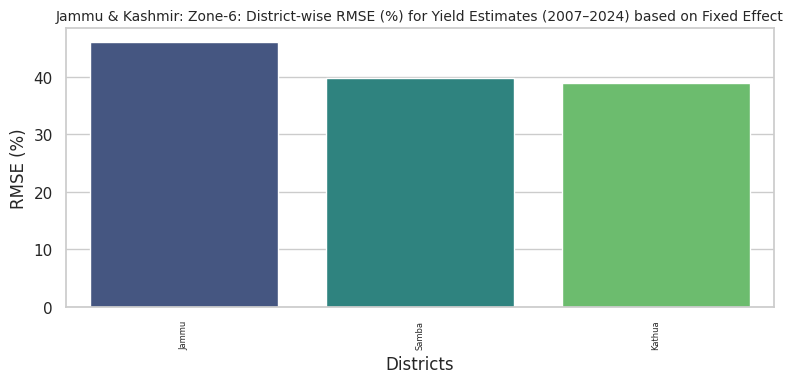

/tmp/ipython-input-3626820577.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


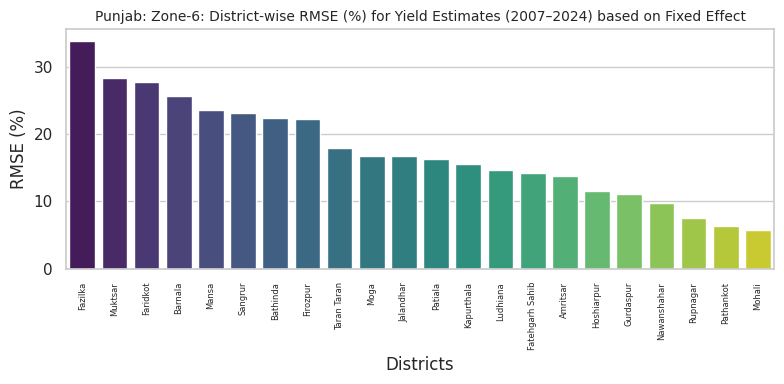

/tmp/ipython-input-3626820577.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


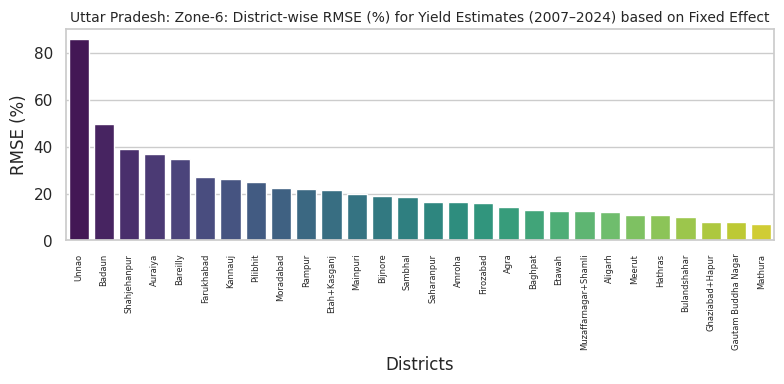

/tmp/ipython-input-3626820577.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


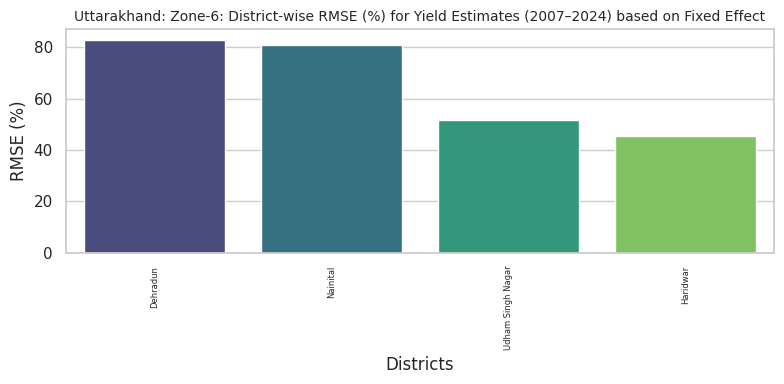

In [3]:
# 1️⃣ Upload  CSV
from google.colab import files
uploaded = files.upload()

# 2️⃣ Read CSV
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv(list(uploaded.keys())[0])

# 3️⃣ Prepare small font theme
sns.set_theme(style="whitegrid", context="notebook")

# Get unique states
states_list = df["state"].unique()

# Function to split list into chunks of size n
def chunks(lst, n):
    for i in range(0, len(lst), n):
        yield lst[i:i + n]

# 4️⃣ Loop through each state separately
for state in states_list:
    df_state = df[df["state"] == state]

    # Get districts for this state
    districts_list = df_state["districts"].unique()

    # Create separate pages with 8 districts each
    for i, group in enumerate(chunks(districts_list, 8), start=1):
        subset = df_state[df_state["districts"].isin(group)]

        g = sns.FacetGrid(
            subset,
            col="districts",
            col_wrap=4,      # 4 columns → 2 rows → 8 plots
            height=2.5,
            sharex=False,
            sharey=False
        )
        g.map_dataframe(
            sns.regplot,
            x="Actual",
            y="Estimated",
            scatter_kws={"alpha":0.6, "s":15},  # small dots
            line_kws={"color":"red", "lw":0.8}  # thin line
        )

        g.set_titles(col_template="{col_name}", size=8)
        g.set_axis_labels("Actual Yield", "Estimated Yield", fontsize=8)

        for ax in g.axes.flatten():
            ax.tick_params(axis='both', labelsize=7)

        plt.subplots_adjust(top=0.9, hspace=0.3)
        g.fig.suptitle(
            f"{state} — District-wise Actual vs Estimated Yield using Fixed Effect — Page {i}",
            fontsize=10
        )

        plt.show()

# Ensure year filter
df_filtered = df[(df["year"] >= 2010) & (df["year"] <= 2022)].copy()

# Function to compute RMSE (%)
def rmse_percent(x):
    errors = ((x["Estimated"] - x["Actual"]) / x["Actual"]) ** 2
    return np.sqrt(errors.mean()) * 100

# Group by state + district and calculate RMSE%
rmse_table = (
    df_filtered
    .groupby(["state", "districts"])
    .apply(rmse_percent)
    .reset_index()
)
rmse_table.columns = ["State", "District", "RMSE (%)"]

# --- Show table ---
pd.set_option("display.max_rows", None)  # show all rows
print(rmse_table)

# --- Optional: save table to CSV ---
rmse_table.to_csv("state_districtwise_RMSE.csv", index=False)

# --- Graphical representation ---
for state in rmse_table["State"].unique():
    subset = rmse_table[rmse_table["State"] == state]

    plt.figure(figsize=(8,4))
    sns.barplot(
        data=subset.sort_values("RMSE (%)", ascending=False),
        x="District", y="RMSE (%)", palette="viridis"
    )
    plt.xticks(rotation=90, fontsize=6)
    plt.title(f"{state}: Zone-6: District-wise RMSE (%) for Yield Estimates (2007–2024) based on Fixed Effect", fontsize=10)
    plt.ylabel("RMSE (%)")
    plt.xlabel("Districts")
    plt.tight_layout()
    plt.show()


